## Ornstein--Uhlenbeck

The Ornstein--Uhlenbeck model is a discrete-time linear stochastic process:
$$
    x_t = a\, x_{t-1} + b + \varepsilon_t, \quad \varepsilon_t \sim
    \mathcal{N}(0, \sigma^2_{\mathrm{OU}}),
$$
with parameters $a = 0.8$, $b = 0.4$, $\sigma_{\mathrm{OU}} = 0.22$,
initial condition $x_0 = -2.0$, and time horizon $T = 30$.

We evaluate the bounded historically property
$$
    \varphi_{\mathrm{OU}} = H_{[0,5]}(1.95 < x < 2.05),
$$
which requires the trajectory to remain within a neighbourhood of radius
$0.05$ around the fixed point $x^\star = 2.0$ during the last five time
steps, i.e.\ for all $t \in \{26, 27, 28, 29, 30\}$.

In [1]:
import torch
from torch.nn.functional import threshold

import numpy as np

from models import ou_model, logistic_model, simulate, plot_traj_set

1) Simulations for Monte Carlo evaluation of the property

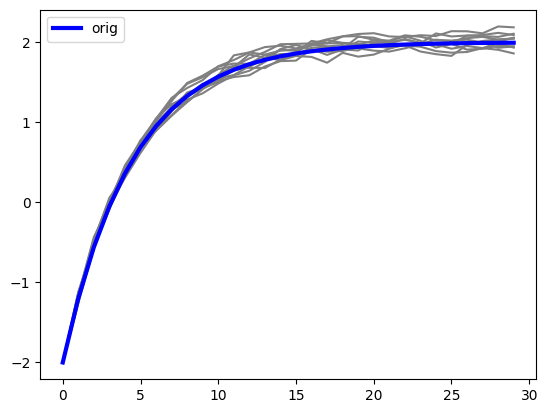

In [2]:
#ornstein uhlembeck process
# X_{t+1} = a*X_t + b + sigma*eps;  eps~normal(0,1)
time = 30
#fast convergence to x=2, with little noise
params = {'time': time,      # time steps
            'init_x':-2.,  # initial x
            'a': 0.88,        #
            'b': 0.24,       #
            'sigma': 0.22}

#slower convergence to x=2, higher variance
params2 = {'time': time,      # time steps
            'init_x':4.,  # initial x
            'a': 0.96,        #
            'b': 0.08,       #
            'sigma': 0.18}


params3 = {'time': time,      # time steps
            'init_x':0.,  # initial x
            'a': 0.9,        #
            'b': 0.0,       #
            'sigma': 0.4}

params4 = {'time': time,      # time steps
            'init_x':-2.,  # initial x
            'a': 0.8,        #
            'b': 0.4,       #
            'sigma': 0.22}

trajs = simulate(ou_model, 10000, params4)

plot_traj_set(trajs, single_traj=10, color='blue', label='orig')

In [3]:
#globally |x| < threshold per set di parametri 3, th = 0.7
#eventually X > threshold per set di parametri 1, th = 2.1
threshold = 2.1
row_max = trajs.max(dim=1).values
#row_min = trajs.min(dim=1).values
tv = (row_max > threshold).int()
#tv = tv * (row_min > -threshold).int()
tv.float().mean()

tensor(0.3044)

In [4]:
col_mu = trajs.mean(dim=0)
col_mu[-1]

tensor(1.9936)

In [5]:
# Calculate mean and variance for the event that in the last 5 steps X is between 1.95 and 2.05
lower, upper = 1.95, 2.05
last_five = trajs[:, -5:]

# Trajectory-level event: all last 5 values are inside [lower, upper]
event_last5_all = ((last_five >= lower) & (last_five <= upper)).all(dim=1).float()
prob_last5_all = event_last5_all.mean()
var_last5_all = event_last5_all.var(unbiased=False)

# Pointwise event over all samples x last-5 time points
event_pointwise_last5 = ((last_five >= lower) & (last_five <= upper)).float()
prob_pointwise_last5 = event_pointwise_last5.mean()
var_pointwise_last5 = event_pointwise_last5.var(unbiased=False)

print('Trajectory-level P(all last 5 in [1.95, 2.05]) =', prob_last5_all.item())
print('Trajectory-level Var(indicator) =', var_last5_all.item())
print('Pointwise P(in [1.95, 2.05] over last 5) =', prob_pointwise_last5.item())
print('Pointwise Var(indicator) =', var_pointwise_last5.item())

{'mean': prob_last5_all.item(), 'variance': var_last5_all.item()}

Trajectory-level P(all last 5 in [1.95, 2.05]) = 0.07919999957084656
Trajectory-level Var(indicator) = 0.07292736321687698
Pointwise P(in [1.95, 2.05] over last 5) = 0.4594799876213074
Pointwise Var(indicator) = 0.2483581304550171


{'mean': 0.07919999957084656, 'variance': 0.07292736321687698}

In [6]:
# Calculate the 95% confidence interval:
from scipy import stats
n = len(event_last5_all)
mean = prob_last5_all.item()
std_err = np.sqrt(var_last5_all.item() / n)
ci_lower = mean - 1.96 * std_err
ci_upper = mean + 1.96 * std_err
print(f'95% CI for P(all last 5 in [1.95, 2.05]): [{ci_lower:.4f}, {ci_upper:.4f}]')



95% CI for P(all last 5 in [1.95, 2.05]): [0.0739, 0.0845]


Monitor Variables

In [7]:
# import module optimization to use DeGAS

import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))

from optimization import *
import matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)

/home/rdoz/miniconda3/envs/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
# COMPILING AND SMOOTHING THE CFG

# Compile SOGA program to a smooth CFG
compiledFile = compile2SOGA('ou_MV.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

In [9]:
#run SOGA
output_dist = start_SOGA(cfg)

In [10]:
#average value of phi
mu = output_dist.gm.mean()[1]
var = output_dist.gm.cov()[1,1]
print(mu,var)
print(output_dist.gm.mean())
print(output_dist.gm.cov())


tensor(0.1065) tensor(0.0952)
tensor([ 1.9950,  0.1065, 30.0000])
tensor([[ 6.5071e-03,  3.7297e-04, -1.1409e-15],
        [ 3.7297e-04,  9.5163e-02,  7.4559e-16],
        [-1.1409e-15,  7.4559e-16,  1.0000e-06]])


In [12]:
mu = output_dist.gm.mean()[1].item()
var = output_dist.gm.cov()[1, 1].item()

std = np.sqrt(var)
ci_lower = mu - 1.96 * std
ci_upper = mu + 1.96 * std

print('standard deviation:', std)
print(f'95% CI for P(all last 5 in [1.95, 2.05]): [{ci_lower:.4f}, {ci_upper:.4f}]')

standard deviation: 0.3084850742058632
95% CI for P(all last 5 in [1.95, 2.05]): [-0.4981, 0.7111]


Direct Integration

In [16]:
compiledFile = compile2SOGA('ou_DI.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

output_dist = start_SOGA(cfg)

In [17]:
from libSOGAshared import ghk_mvnorm_prob

# Probability that the last five time steps stay in [1.95, 2.05]
lower, upper = 1.95, 2.05
last_five_idx = list(range(25,30))
idx_tensor = torch.tensor(last_five_idx)
A = torch.full((5,), lower, dtype=output_dist.gm.mu.dtype, device=output_dist.gm.mu.device)
B = torch.full((5,), upper, dtype=output_dist.gm.mu.dtype, device=output_dist.gm.mu.device)

prob_last_five = torch.zeros((), dtype=output_dist.gm.mu.dtype, device=output_dist.gm.mu.device)
for k in range(output_dist.gm.n_comp()):
    mu_k = output_dist.gm.mu[k, last_five_idx]
    sigma_k = output_dist.gm.sigma[k][idx_tensor.unsqueeze(1), idx_tensor]
    prob_k = ghk_mvnorm_prob(mu_k, sigma_k, A, B)
    prob_last_five = prob_last_five + output_dist.gm.pi[k].squeeze() * prob_k

print(f'P(last 5 in [1.95, 2.05]) = {prob_last_five.item():.6f}')

P(last 5 in [1.95, 2.05]) = 0.082371


In [19]:
import botorch.utils.probability.mvnxpb as mvn

# Same event as above, but using MVNXPB directly as in libSOGAshared.
lower, upper = 1.95, 2.05
last_five_idx = list(range(25,30))
idx_tensor = torch.tensor(last_five_idx)

prob_last_five_mvnxpb = torch.zeros((), dtype=output_dist.gm.mu.dtype, device=output_dist.gm.mu.device)
for k in range(output_dist.gm.n_comp()):
    mu_k = output_dist.gm.mu[k, last_five_idx]
    sigma_k = output_dist.gm.sigma[k][idx_tensor.unsqueeze(1), idx_tensor]
    bounds = torch.stack([
        torch.tensor([lower - mu_k[i], upper - mu_k[i]], dtype=mu_k.dtype, device=mu_k.device)
        for i in range(mu_k.numel())
    ])
    result = torch.exp(mvn.MVNXPB(covariance_matrix=sigma_k, bounds=bounds).solve())
    if torch.isnan(result):
        sigma_k = (sigma_k + sigma_k.T) / 2
        result = torch.exp(mvn.MVNXPB(covariance_matrix=sigma_k, bounds=bounds).solve())
    prob_last_five_mvnxpb = prob_last_five_mvnxpb + output_dist.gm.pi[k].squeeze() * result

print(f'P(last 5 in [1.95, 2.05]) via MVNXPB = {prob_last_five_mvnxpb.item():.6f}')

P(last 5 in [1.95, 2.05]) via MVNXPB = 0.096591
